# Credit Score Predictor — TensorFlow / Keras

**Dataset:** `comprehensive_loan_data.csv` | **Target:** `Repayment_Status` (0 = Default, 1 = Repaid)

In [5]:
pip install numpy pandas matplotlib scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 549 kB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 193 kB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 190 kB/s eta 0:00:01
     |████████████████████████████████| 200.4 MB 4.4 kB/s eta 0:00:01     |████████████████████████▏       | 151.2 MB 202 kB/s eta 0:04:04     |████████████████████████████▌   | 178.8 MB 152 kB/s eta 0:02:22
     |████████████████████████████████| 510 kB 558 kB/s eta 0:00:01
     |████████████████████████████████| 348 kB 532 kB/s eta 0:00:01
     |████████████████████████████████| 249 kB 367 kB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 574 kB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 364 kB/s eta 0:00:01
     |████████████████████████████████| 64 kB 537 kB/s eta 0:00:01
     |████████████████████████████████| 122 kB 506 kB/s eta 0:00:01
     |███████████████████████████

In [6]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)

try:
    import tensorflow as tf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])
    import tensorflow as tf

RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow {tf.__version__}  |  GPUs: {len(tf.config.list_physical_devices('GPU'))}")

/Users/mac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow 2.20.0  |  GPUs: 0


In [7]:
df = pd.read_csv('comprehensive_loan_data.csv')

# Encode features
df['Payment_History'] = df['Payment_History'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3})
df = pd.get_dummies(df, columns=['Employment_Status'], drop_first=True)

TARGET   = 'Repayment_Status'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].values.astype('float32')
y = df[TARGET].values.astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test  = scaler.transform(X_test).astype('float32')

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Class split — 0: {int((y_test==0).sum())}  1: {int((y_test==1).sum())}")

Train: (8000, 11)  Test: (2000, 11)
Class split — 0: 604  1: 1396


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7669 - auc: 0.8121 - loss: 0.4613 - val_accuracy: 0.8867 - val_auc: 0.9508 - val_loss: 0.2573
Epoch 2/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8858 - auc: 0.9463 - loss: 0.2682 - val_accuracy: 0.8867 - val_auc: 0.9519 - val_loss: 0.2537
Epoch 3/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8905 - auc: 0.9527 - loss: 0.2535 - val_accuracy: 0.8833 - val_auc: 0.9514 - val_loss: 0.2567
Epoch 4/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8893 - auc: 0.9532 - loss: 0.2508 - val_accuracy: 0.8842 - val_auc: 0.9518 - val_loss: 0.2534
Epoch 5/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.8962 - auc: 0.9564 - loss: 0.2428 - val_accuracy: 0.8842 - val_auc: 0.9517 - val_loss: 0.2532
Epoch 6/40
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8954 - auc: 0.9568 - loss: 0.2405 - val_accuracy: 0.8842 - val_auc: 0.9527 - val_loss: 0.2491
Epoch 7/40
213/213 ━━━━━━━━━━━━━━━━━

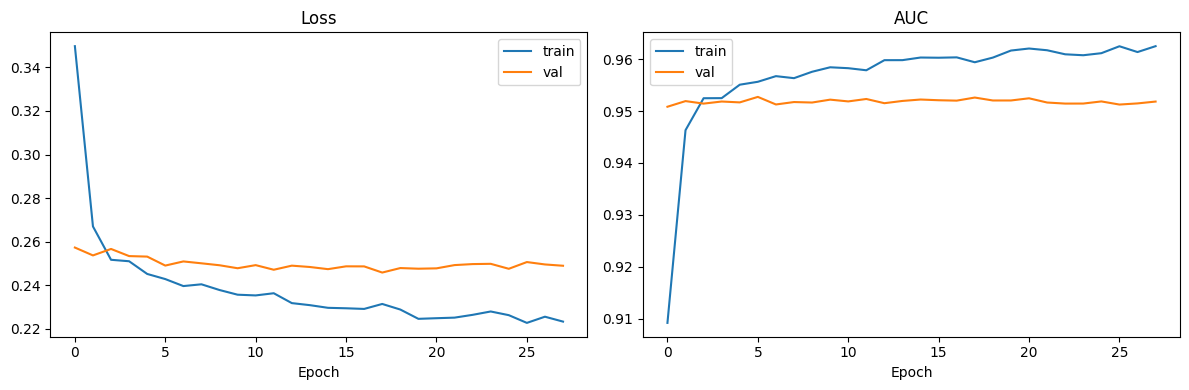

In [8]:
n_features = X_train.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
)
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        ),
    ],
    verbose=1,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set(title='Loss', xlabel='Epoch')
axes[0].legend()
axes[1].plot(history.history['auc'], label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set(title='AUC', xlabel='Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 900us/step
Accuracy : 0.8925
ROC-AUC  : 0.9596

              precision    recall  f1-score   support

 Default (0)       0.85      0.78      0.81       604
  Repaid (1)       0.91      0.94      0.92      1396

    accuracy                           0.89      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.89      0.89      0.89      2000



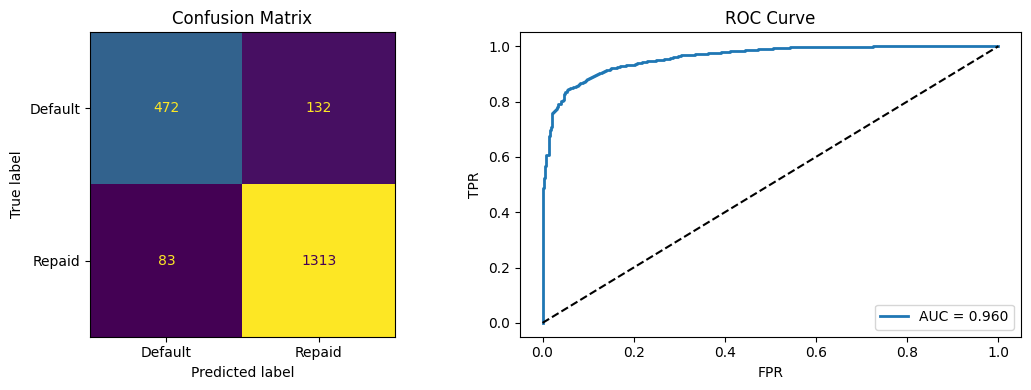

In [9]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Default (0)', 'Repaid (1)']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Default', 'Repaid'],
    ax=axes[0], colorbar=False,
)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
import joblib

os.makedirs('models', exist_ok=True)
model.save('models/credit_score_model.h5')
joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(FEATURES, 'models/features.pkl')

print("Saved:")
print("  models/credit_score_model.h5  — Keras model")
print("  models/scaler.pkl             — StandardScaler")
print("  models/features.pkl           — feature name list")

Saved:
  models/credit_score_model.h5  — Keras model
  models/scaler.pkl             — StandardScaler
  models/features.pkl           — feature name list
